# Rich single-sample graph-state visualization

This notebook studies **one response graph at a time**. The primary response-node representation is a 32-D deterministic graph state built from incoming prompt/history routing, sparsity, concentration, locality, and early/middle/late layer routing. t-SNE is fitted without hallucination labels; labels are added only afterwards for diagnostic coloring.

The main phase view distinguishes `far normal`, `pre-error`, `hallucination`, and `post-error`. A separate all-token source-role view includes prompt tokens; because it summarizes how a token is used by later response queries, it is descriptive rather than causal.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from rich_visualization import RichSampleVisualizer

DATA_ROOT = Path(
    "/share/home/tm902089733300000/a903202310/lys/data/RAGTruth/"
    "model_traces/llama31_8b/test"
)
OUTPUT_ROOT = REPO_ROOT / "outputs" / "single_sample_rich"

ERROR_INDEX = 0
ERROR_SAMPLE_ID = None  # e.g. "10071"; None uses ERROR_INDEX
PRE_WINDOW = 10
POST_WINDOW = 10
HEATMAP_RADIUS = 18


In [2]:
viewer = RichSampleVisualizer(
    DATA_ROOT,
    output_root=OUTPUT_ROOT,
    device="cpu",
    verify_hashes=False,
    random_state=0,
)

print("total samples:", len(viewer.dataset))
print("hallucinated samples:", len(viewer.error_sample_ids))
print("fully correct samples:", len(viewer.correct_sample_ids))
viewer.list_errors(limit=10)


total samples: 449
hallucinated samples: 226
fully correct samples: 223


[{'sample_id': '10071',
  'source_id': '14778',
  'split': 'test',
  'task_type': 'Data2txt',
  'data_source': 'Yelp',
  'generator_model': 'llama-2-7b-chat',
  'observer_model': 'Meta-Llama-3.1-8B-Instruct',
  'temperature': 0.7,
  'quality': 'good',
  'response_tokens': 134,
  'positive_runs': [[81, 84], [85, 87]]},
 {'sample_id': '10113',
  'source_id': '14785',
  'split': 'test',
  'task_type': 'Data2txt',
  'data_source': 'Yelp',
  'generator_model': 'llama-2-7b-chat',
  'observer_model': 'Meta-Llama-3.1-8B-Instruct',
  'temperature': 0.775,
  'quality': 'good',
  'response_tokens': 148,
  'positive_runs': [[112, 120], [121, 122]]},
 {'sample_id': '10209',
  'source_id': '14802',
  'split': 'test',
  'task_type': 'Data2txt',
  'data_source': 'Yelp',
  'generator_model': 'llama-2-7b-chat',
  'observer_model': 'Meta-Llama-3.1-8B-Instruct',
  'temperature': 0.7,
  'quality': 'good',
  'response_tokens': 146,
  'positive_runs': [[94, 96], [112, 122]]},
 {'sample_id': '10365',
  'sourc

## Select one hallucinated sample

Set `ERROR_SAMPLE_ID` above for an exact sample, or change `ERROR_INDEX`.


In [3]:
sample_id = (
    str(ERROR_SAMPLE_ID)
    if ERROR_SAMPLE_ID is not None
    else viewer.error_sample_ids[ERROR_INDEX]
)
print("selected sample:", sample_id)
print("positive runs:", viewer.labels.positive_runs(sample_id))
print("metadata:", viewer.dataset[sample_id].metadata)


selected sample: 10071
positive runs: [[81, 84], [85, 87]]
metadata: {'sample_id': '10071', 'source_id': '14778', 'split': 'test', 'task_type': 'Data2txt', 'data_source': 'Yelp', 'generator_model': 'llama-2-7b-chat', 'observer_model': 'Meta-Llama-3.1-8B-Instruct', 'temperature': 0.7, 'quality': 'good'}


## One-call rich diagnostic bundle

This generates the response-node phase projection, multi-perplexity stability view, prompt/response source-role projection, onset-centered feature heatmap, pre-error→hallucination feature-change plot, and a joint projection with a matched correct control.


{'sample_id': '10071',
 'positive_runs': [[81, 84], [85, 87]],
 'response_nodes': 134,
 'rich_response_dimensions': 32,
 'source_role_dimensions': 12,
 'pre_window': 10,
 'post_window': 10,
 'matched_control_sample_id': '6771',
 'metrics': {'hallucination_nodes': 5,
  'pre_error_nodes': 11,
  'normal_nodes': 129,
  'silhouette_error_vs_normal': -0.09919025748968124,
  'centroid_distance_error_vs_pre': 3.0701751708984375},
 'representation_note': 'Response projection is incoming-only and causal with respect to the current response position. All-token source-role projection is descriptive and uses future response queries.'}

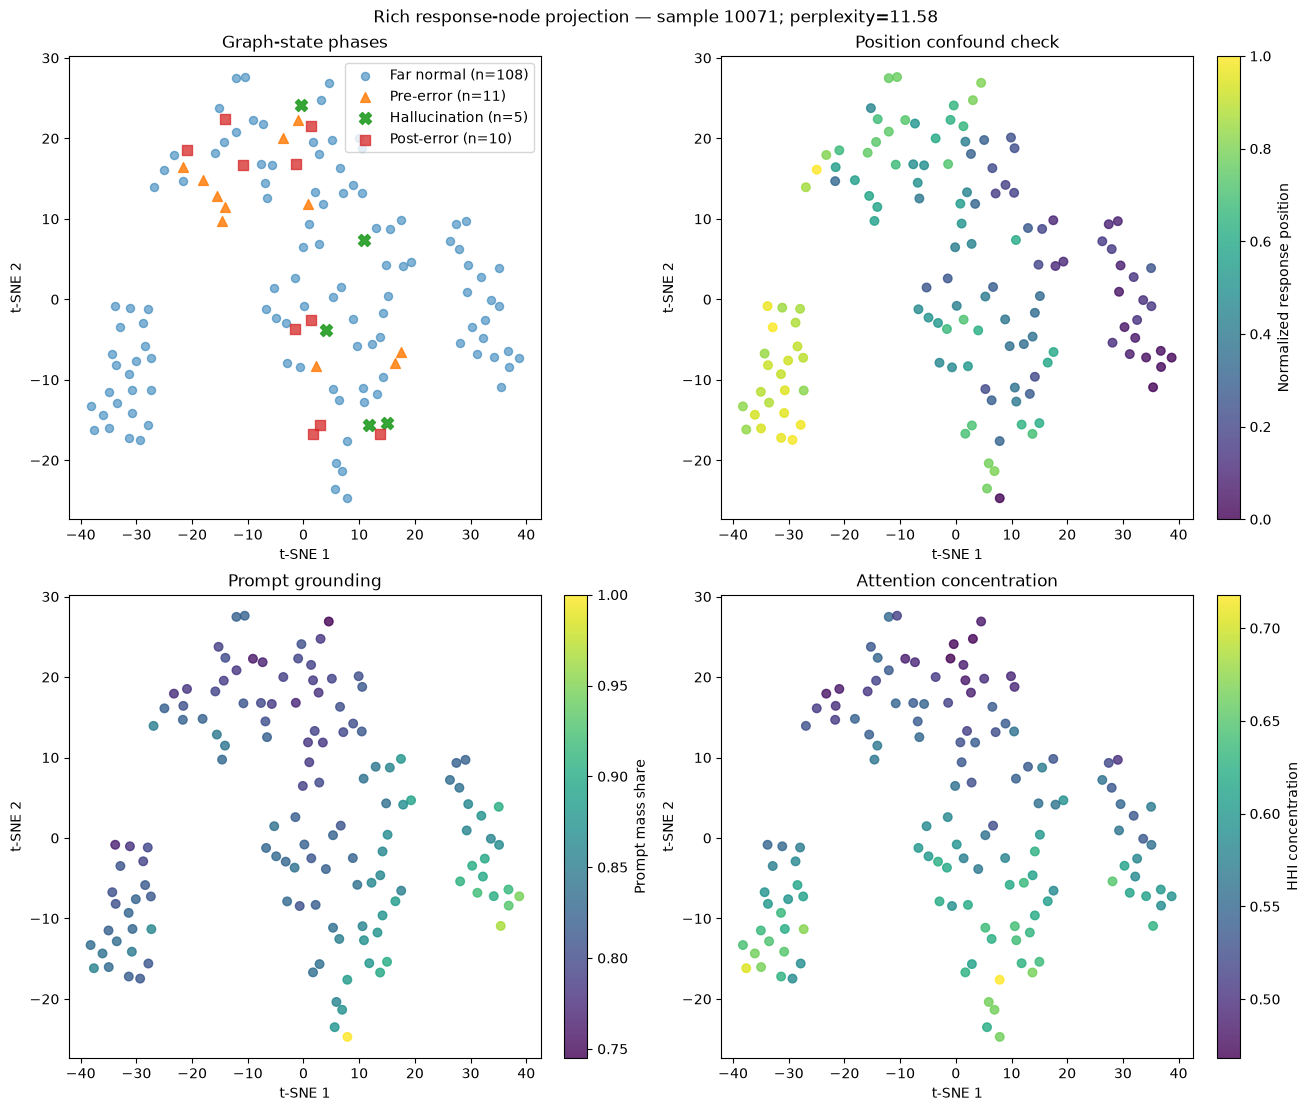

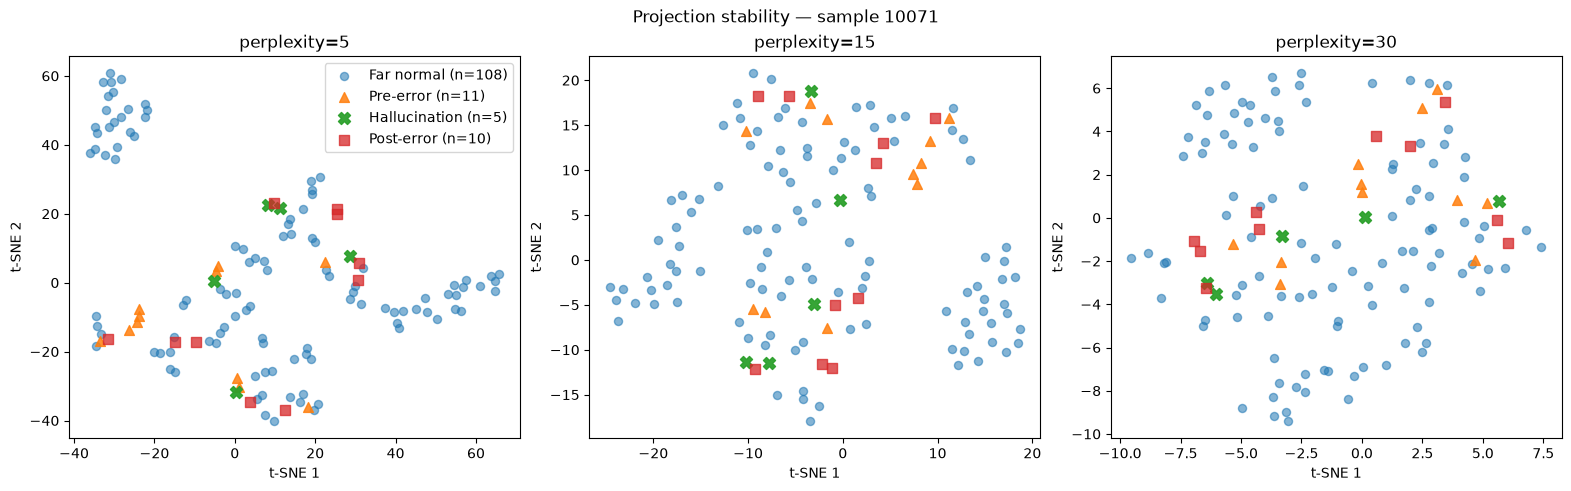

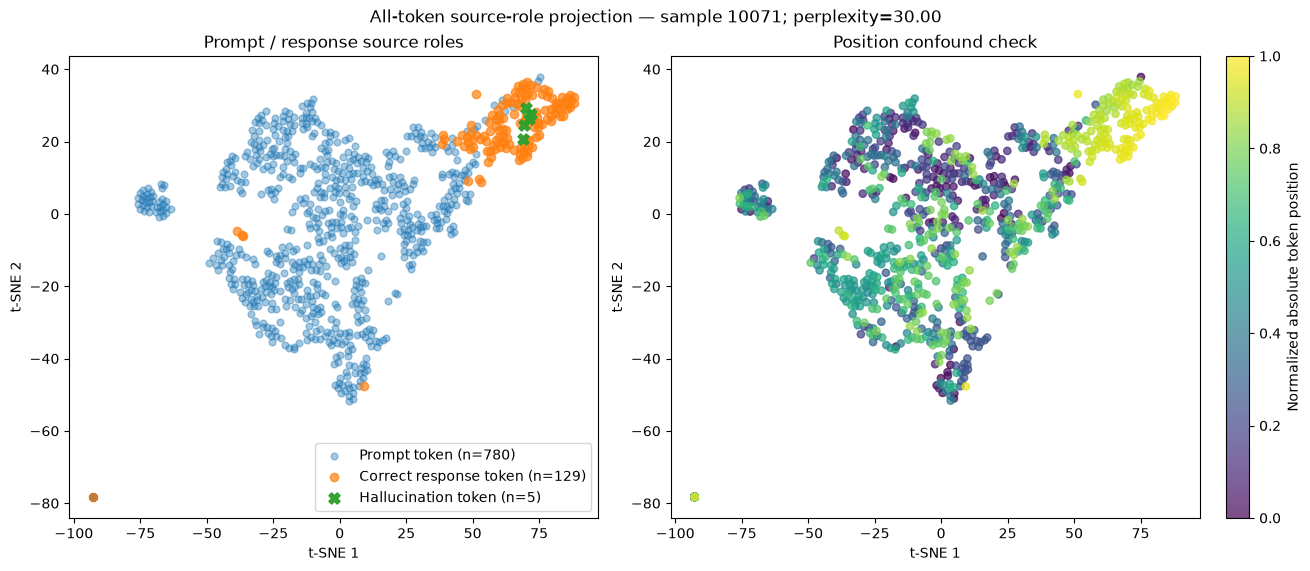

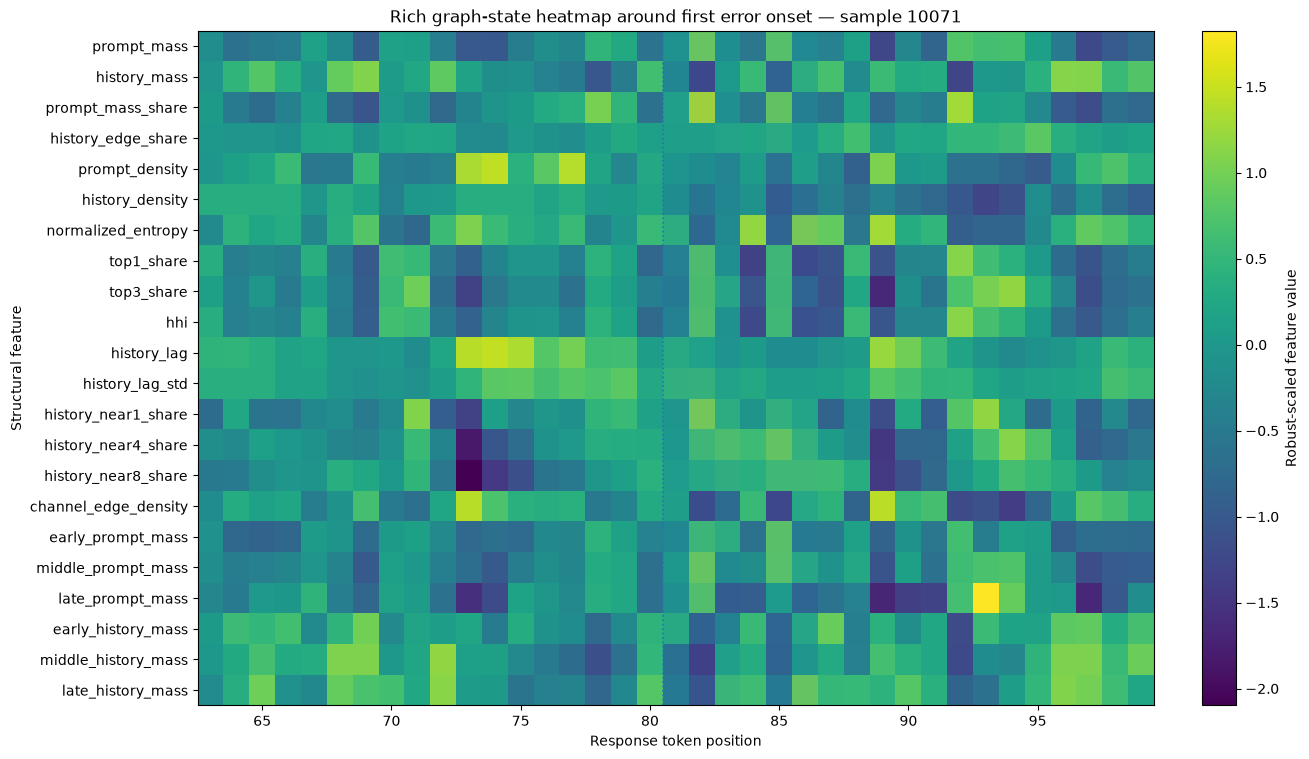

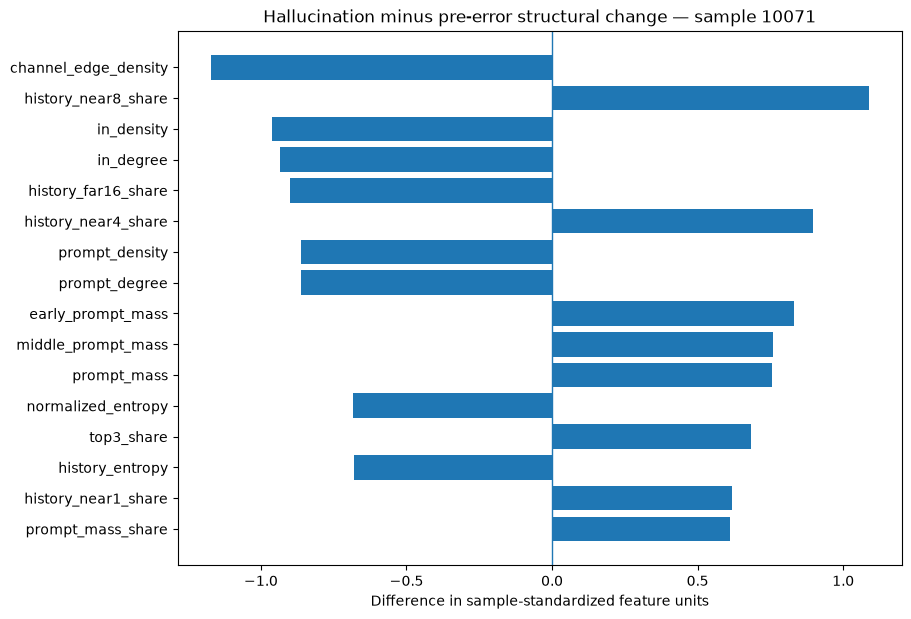

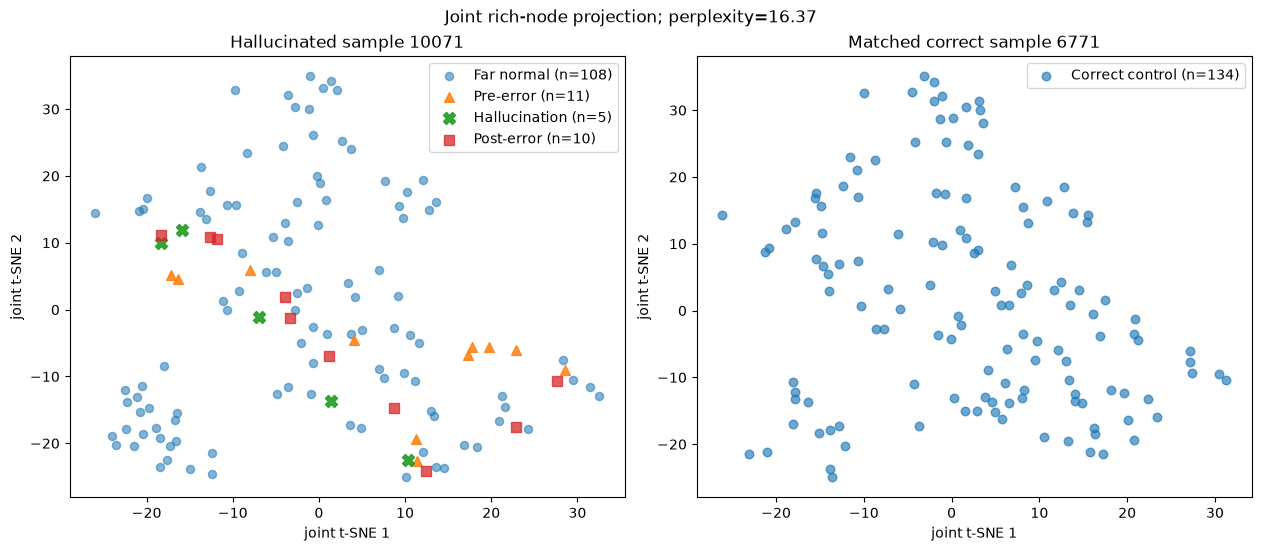

In [4]:
result = viewer.visualize(
    sample_id,
    pre_window=PRE_WINDOW,
    post_window=POST_WINDOW,
    heatmap_radius=HEATMAP_RADIUS,
    include_control=True,
)
result["metadata"]


## Display the saved figures


rich_response_tsne.png


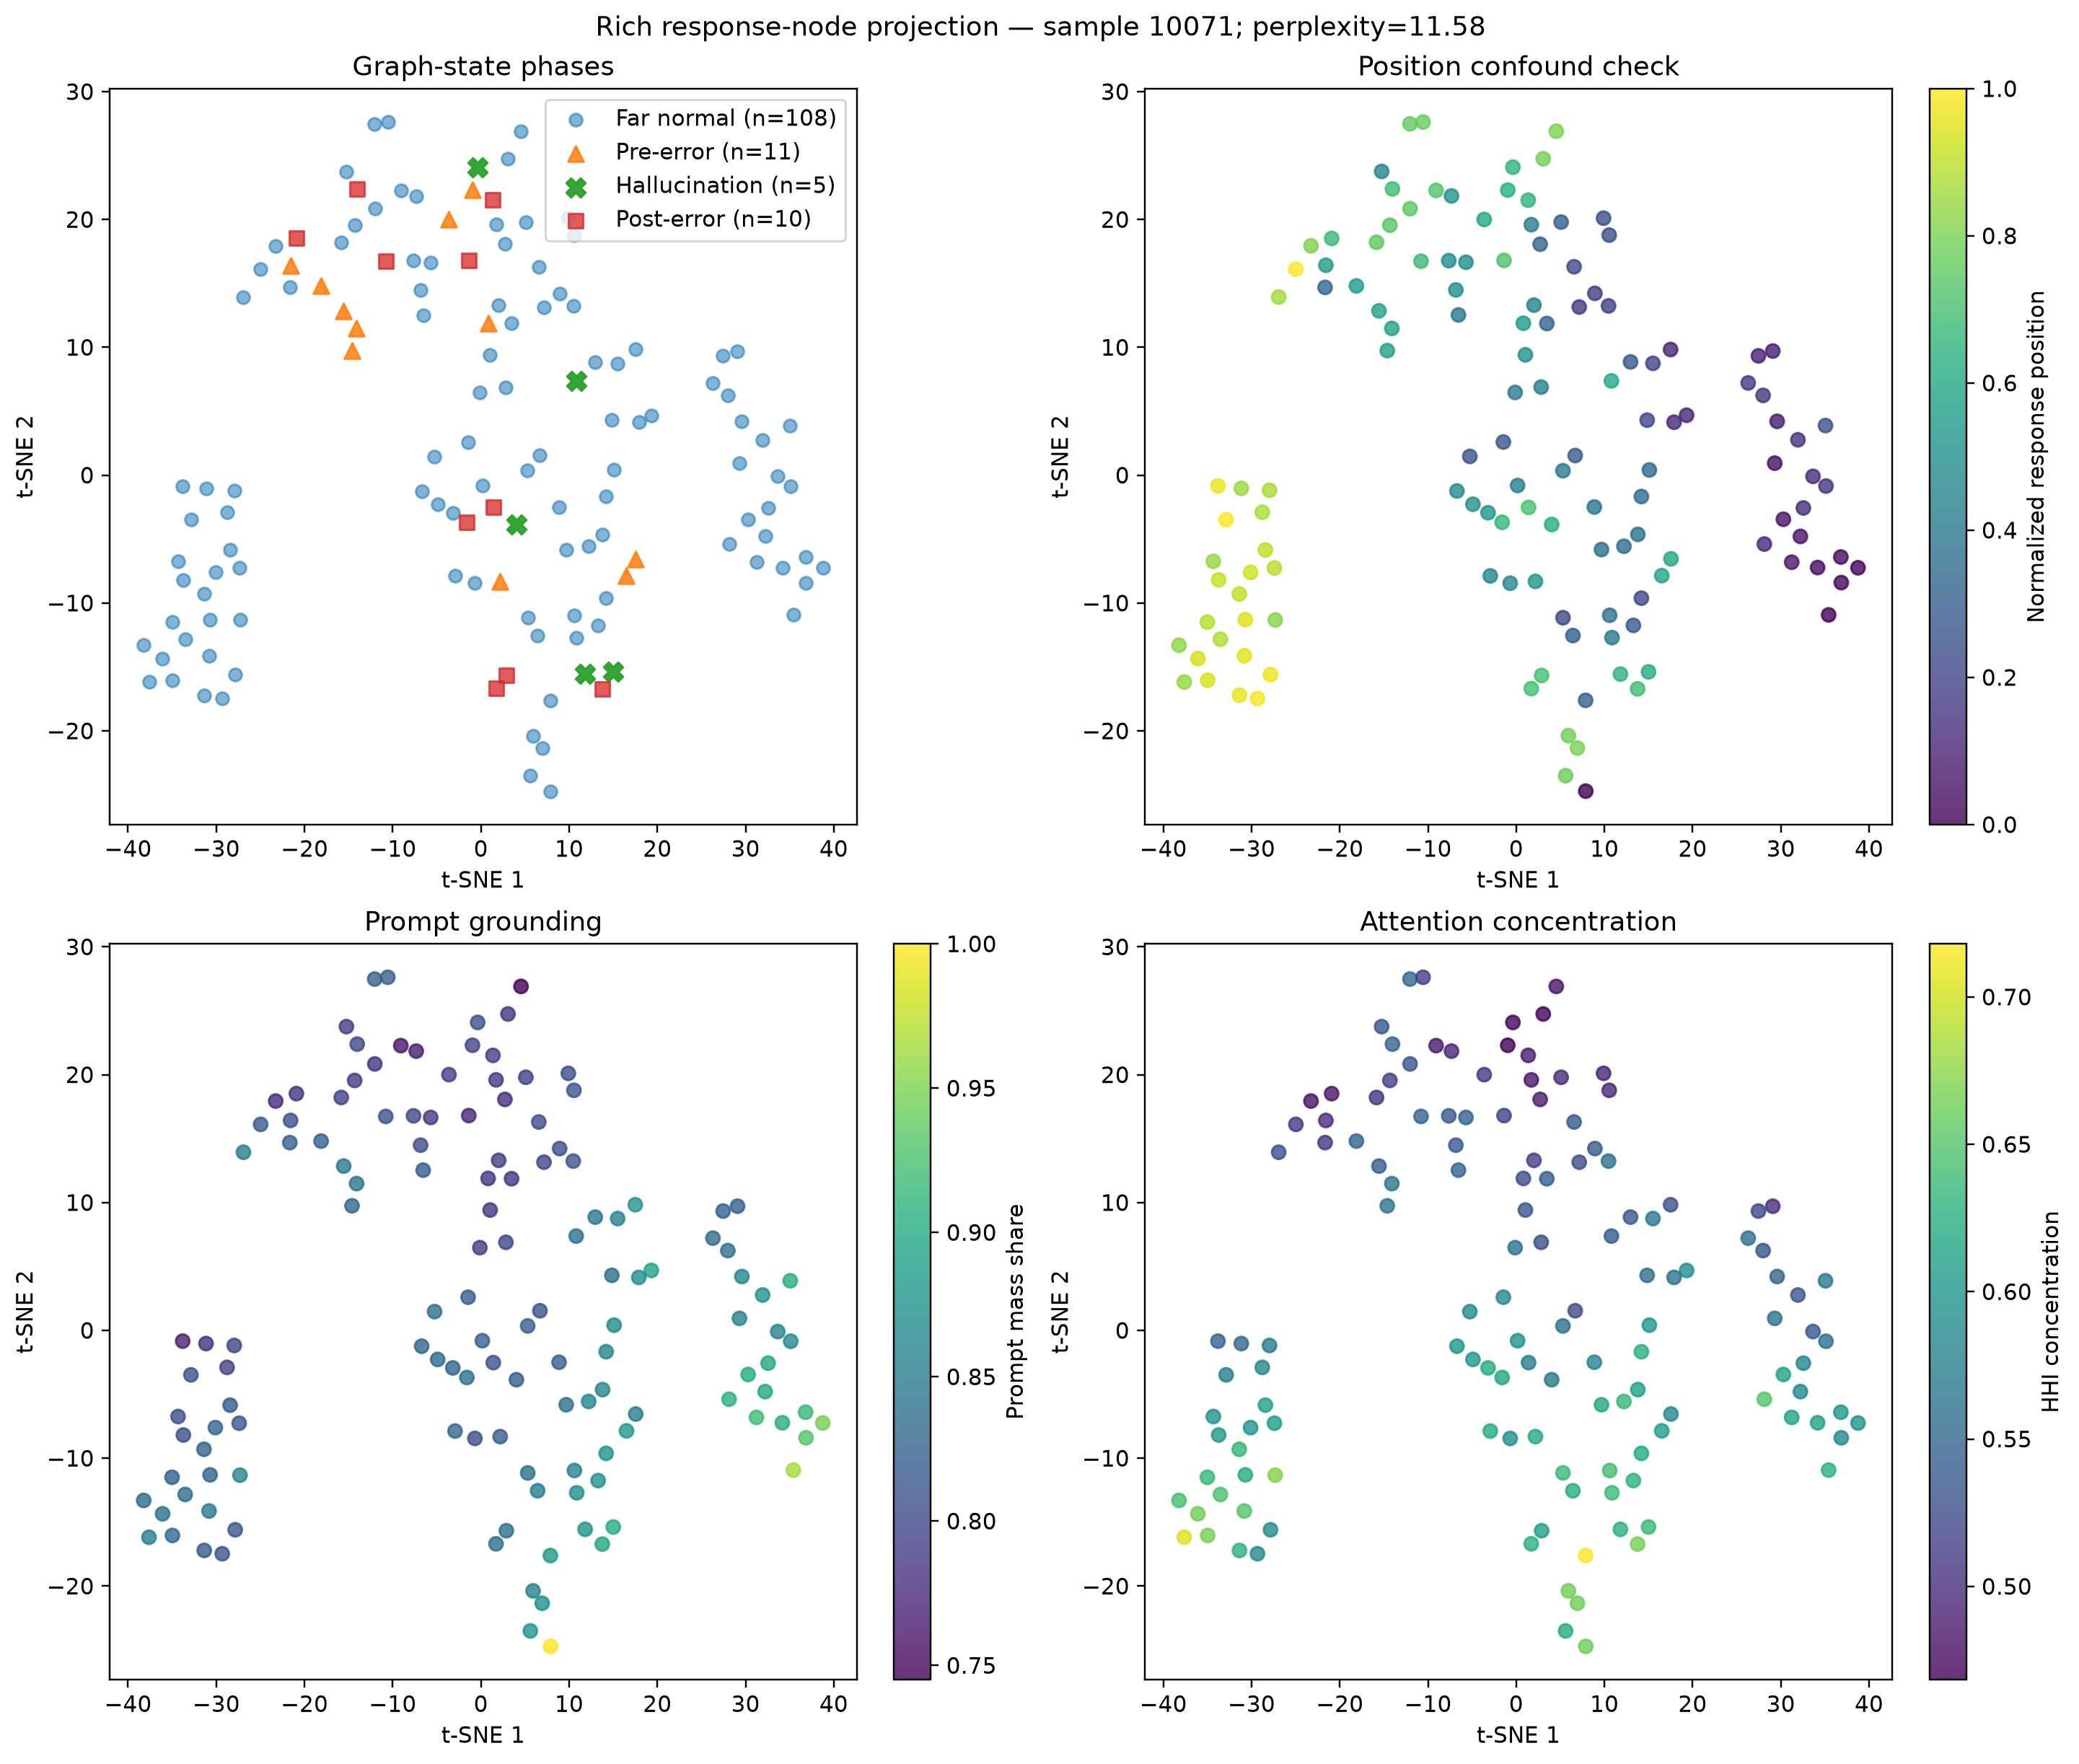

projection_stability.png


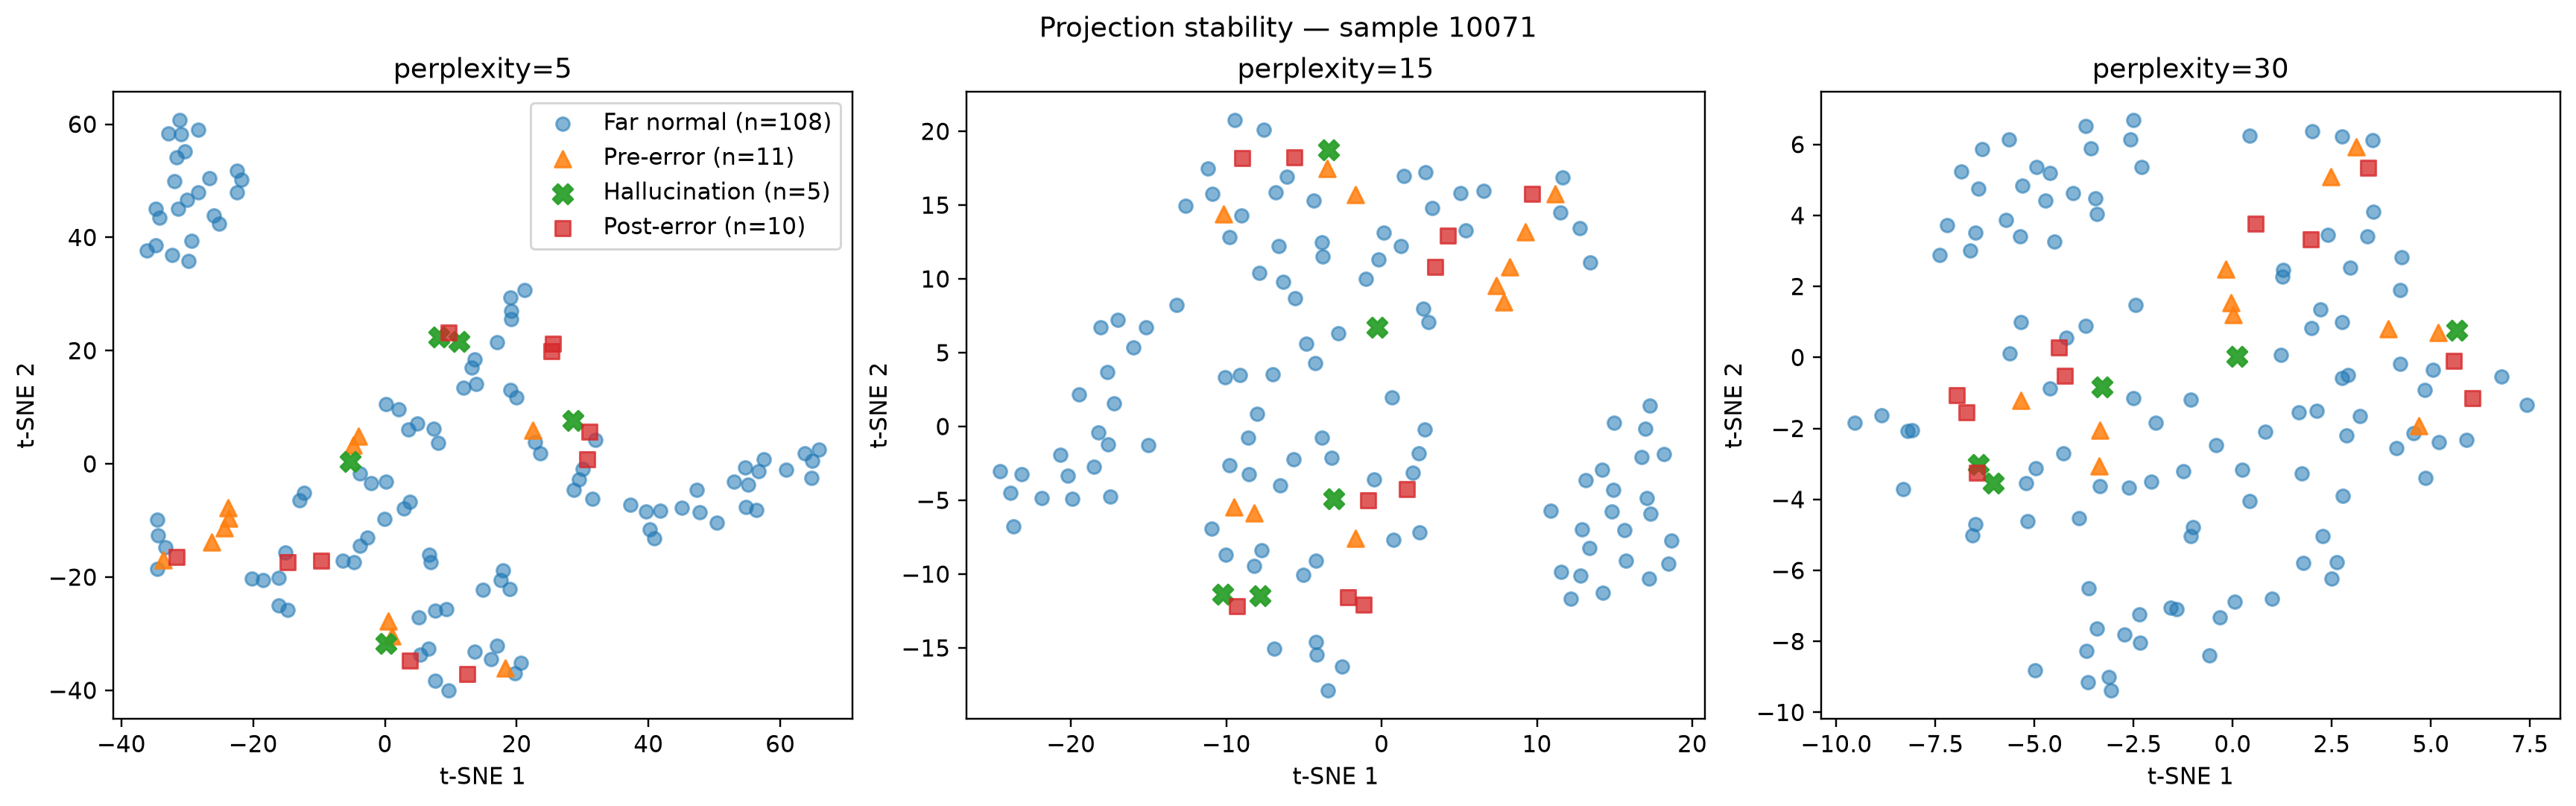

source_role_tsne.png


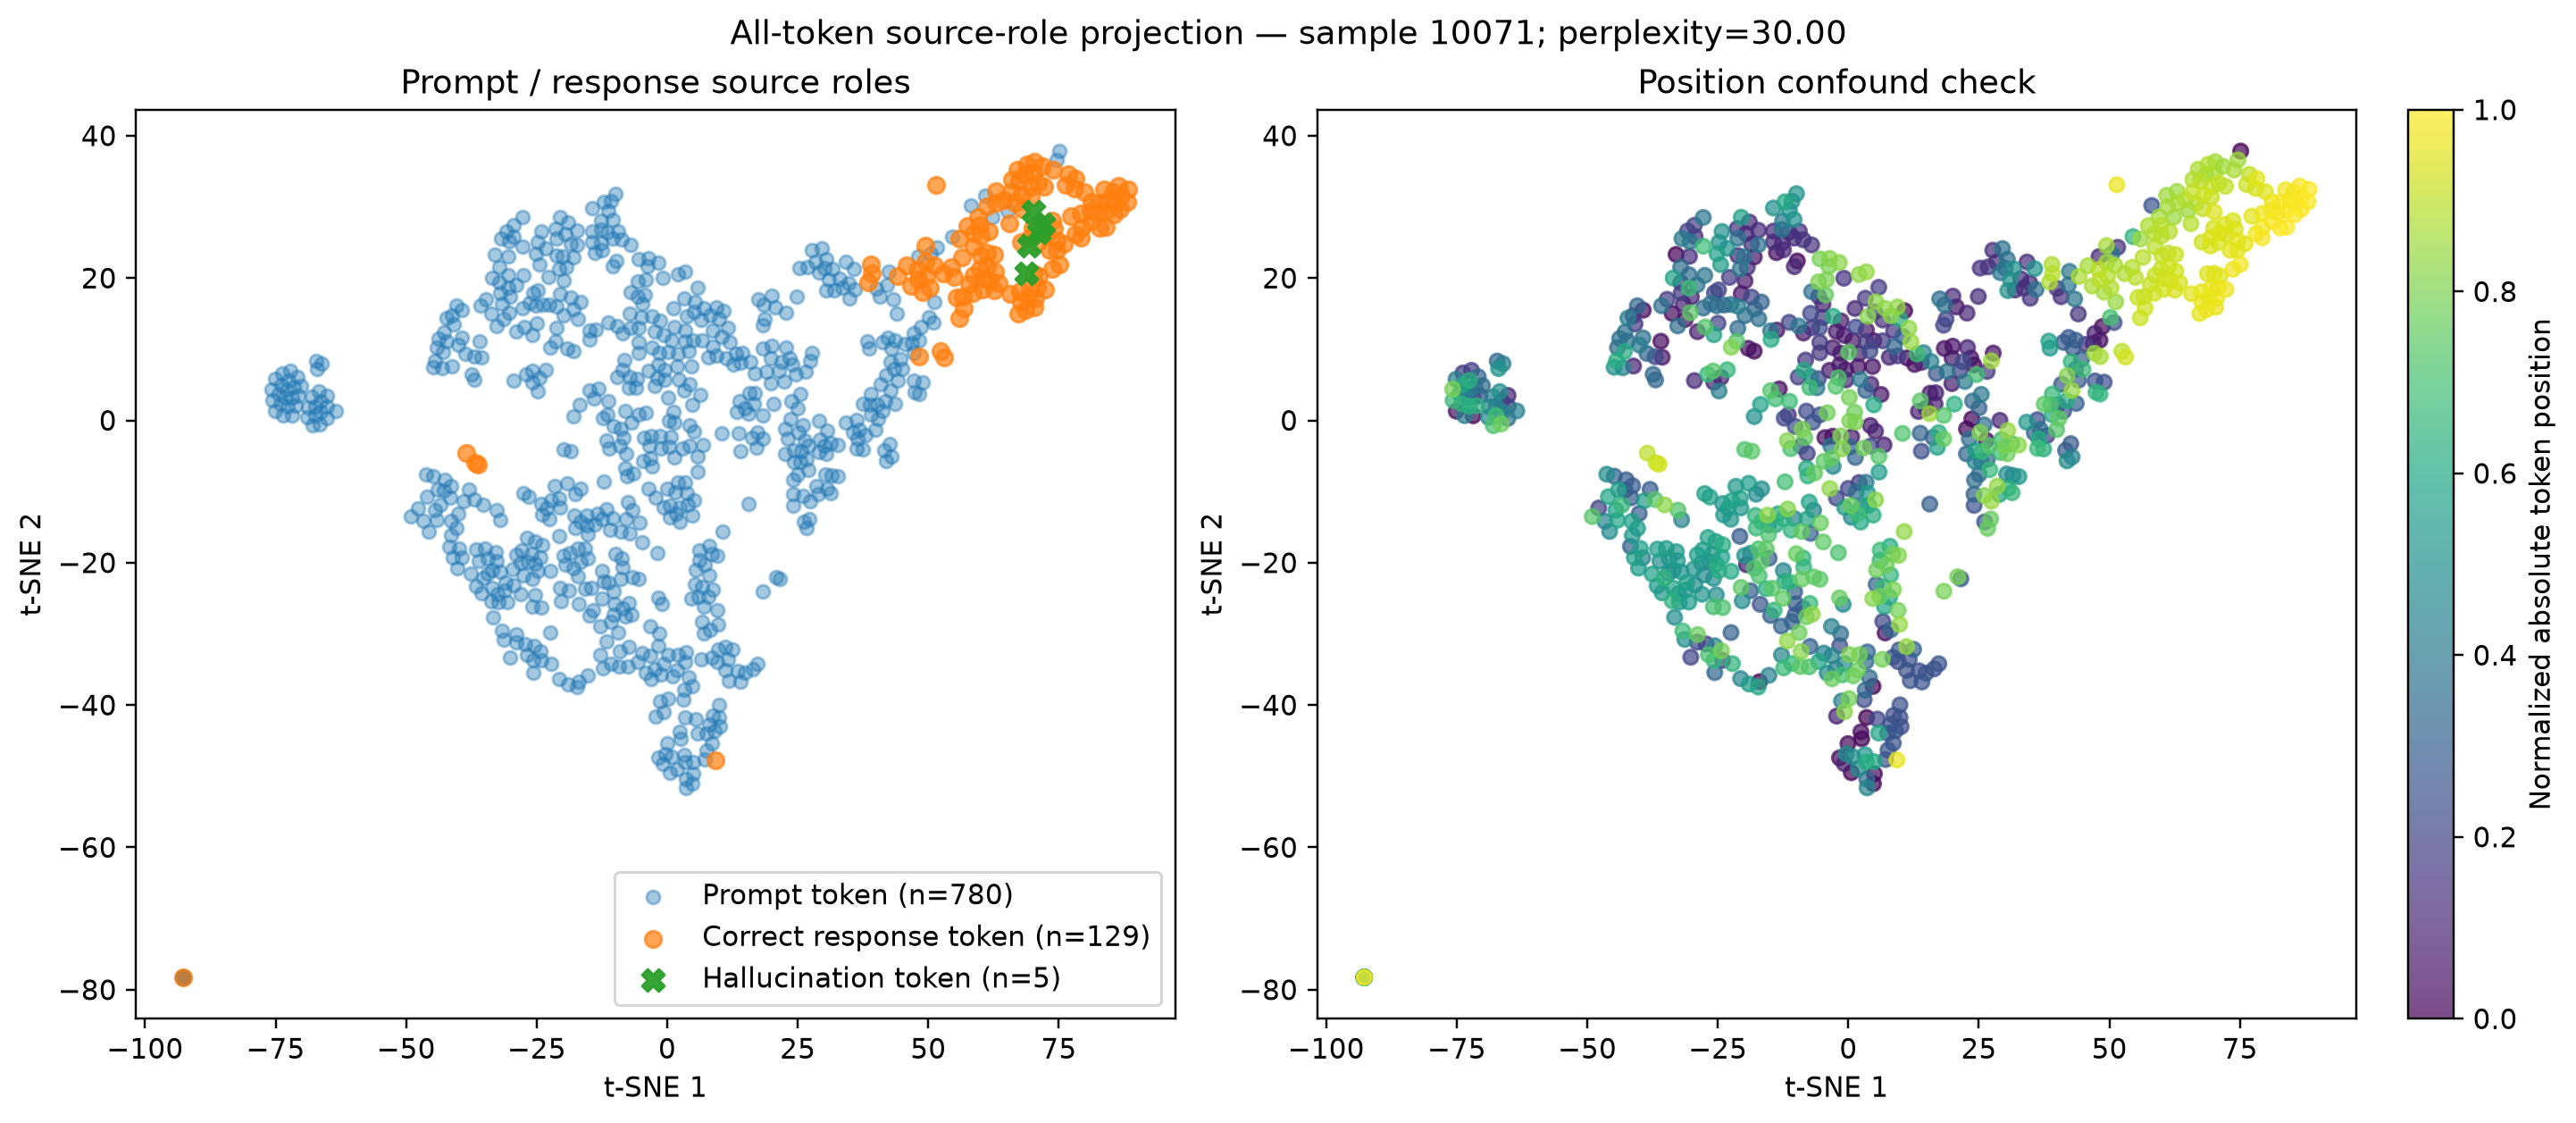

rich_feature_heatmap.png


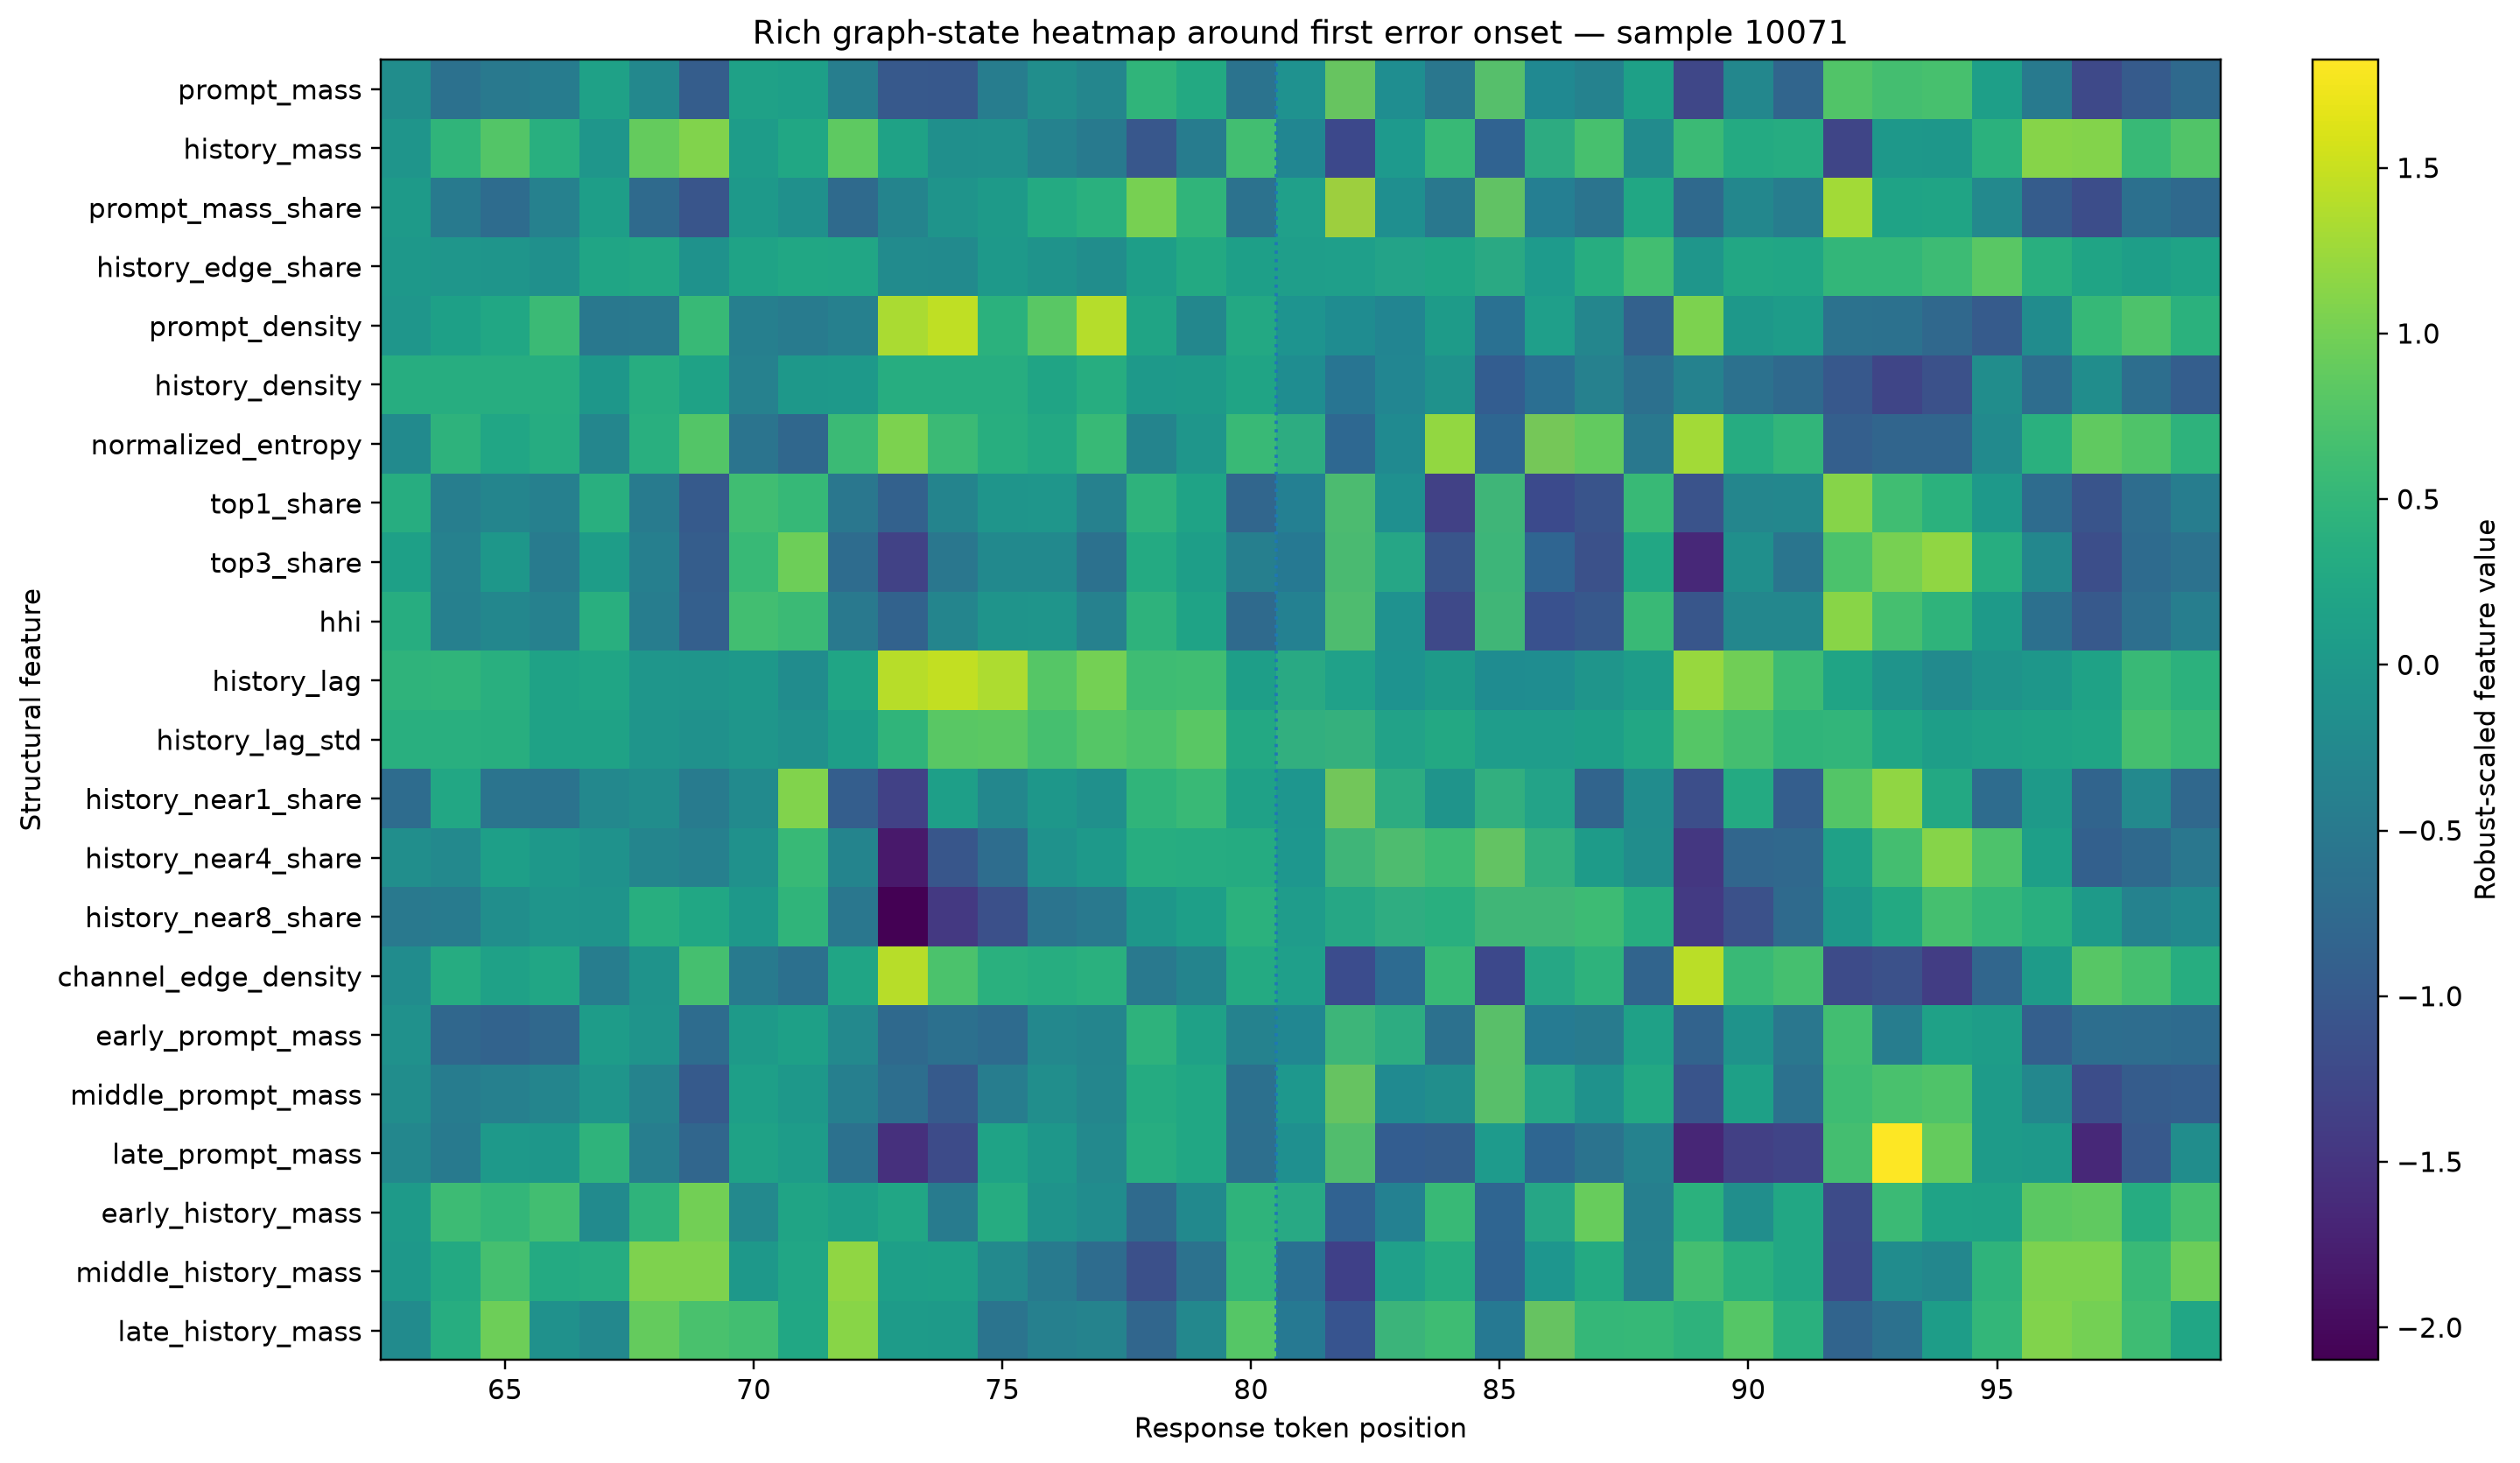

rich_feature_differences.png


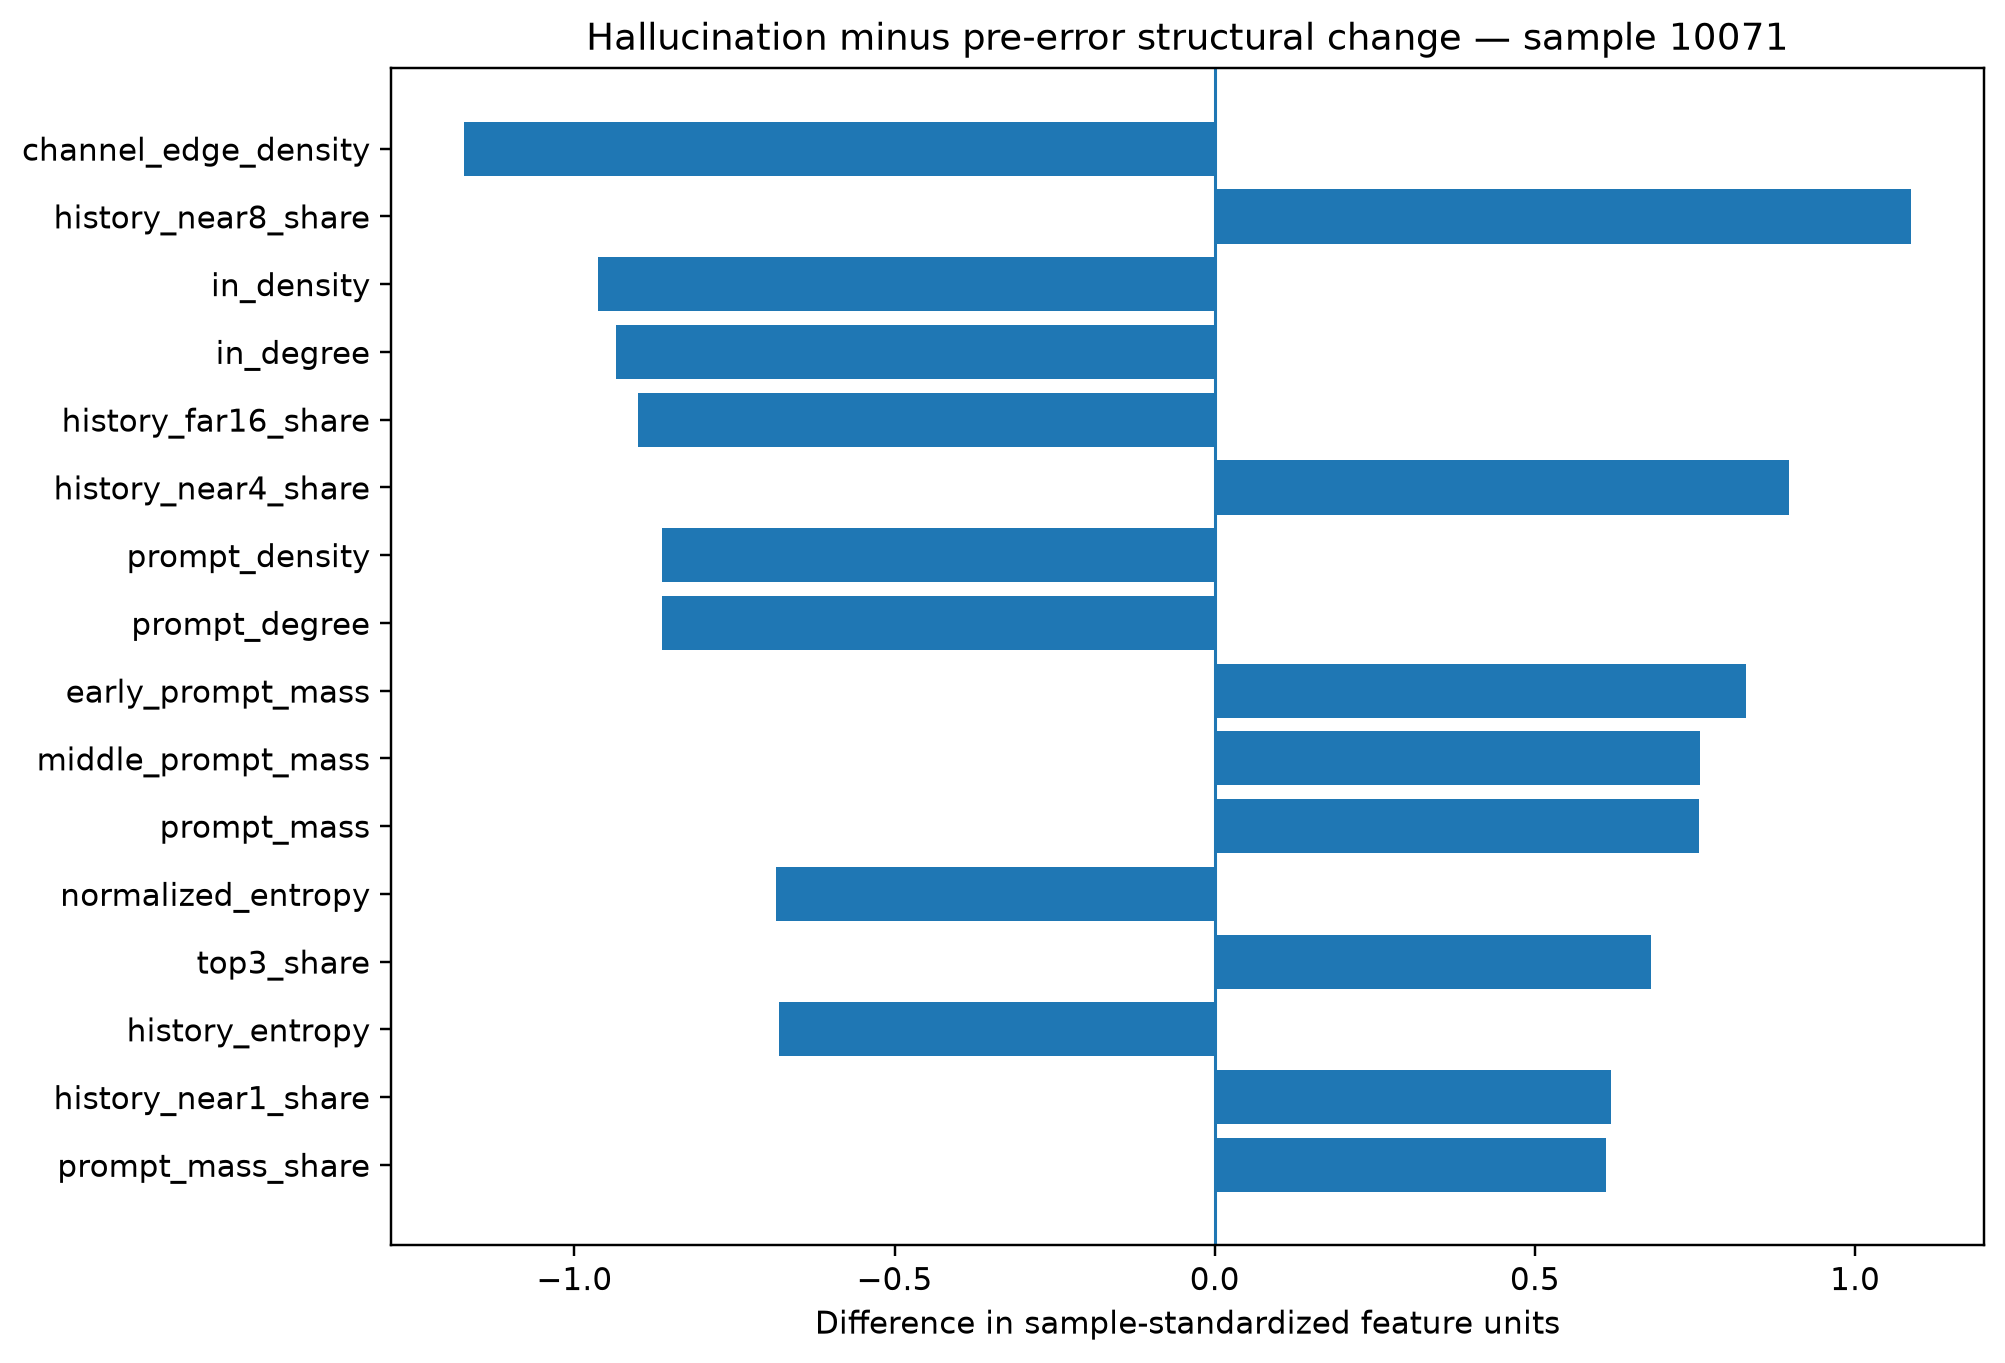

matched_control_joint_tsne.png


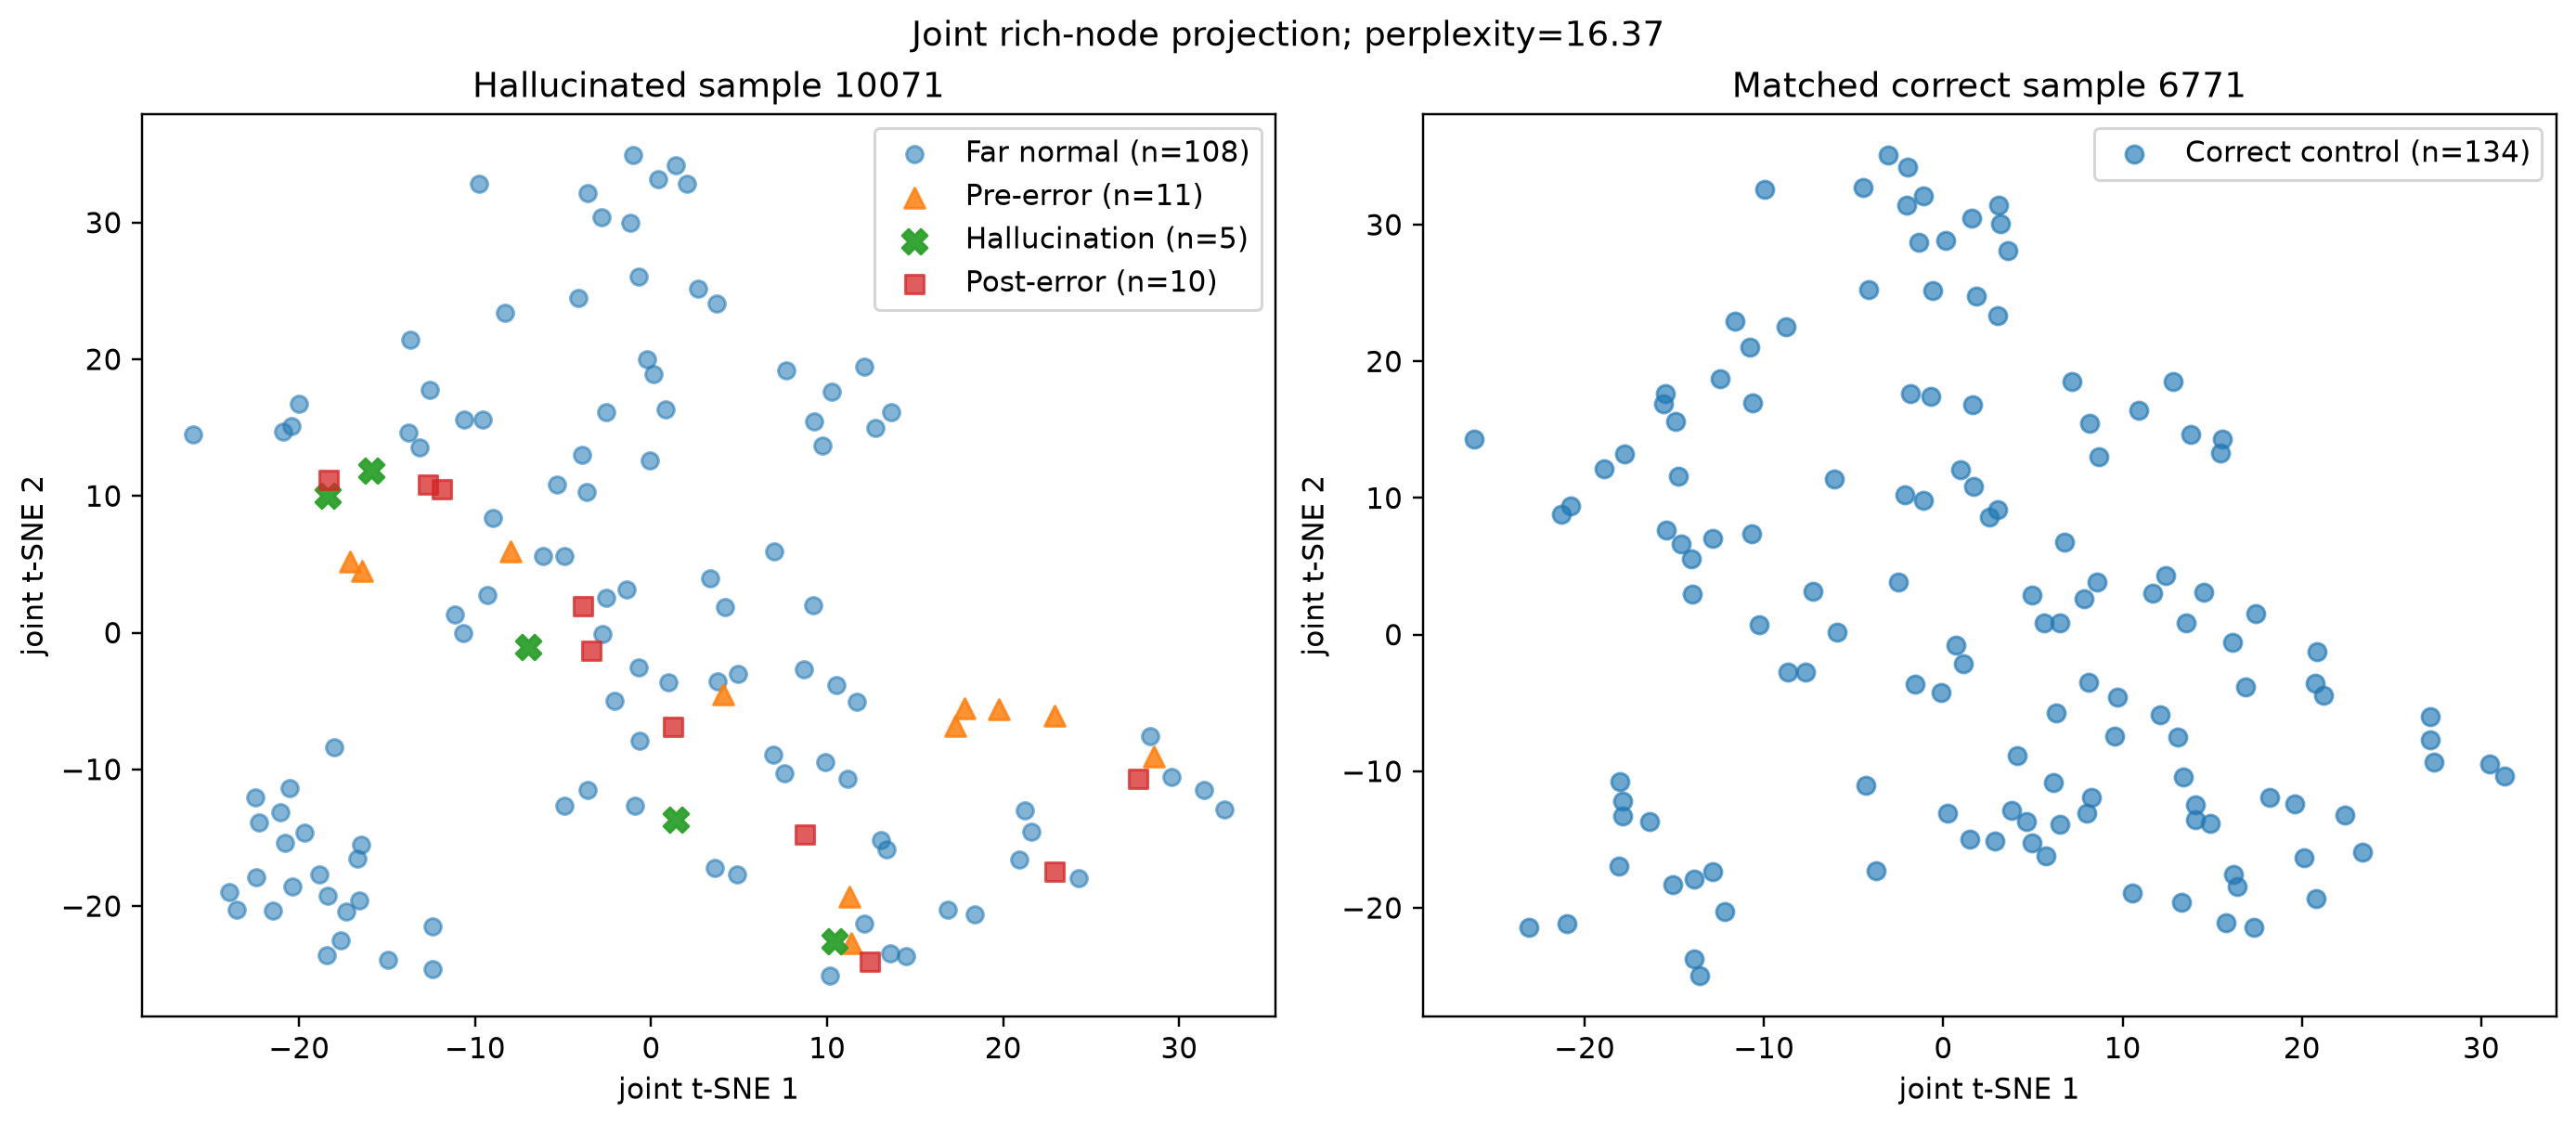

In [5]:
from IPython.display import Image, display

sample_output = OUTPUT_ROOT / sample_id
for filename in (
    "rich_response_tsne.png",
    "projection_stability.png",
    "source_role_tsne.png",
    "rich_feature_heatmap.png",
    "rich_feature_differences.png",
    "matched_control_joint_tsne.png",
):
    path = sample_output / filename
    if path.is_file():
        print(filename)
        display(Image(filename=str(path)))


## Quantitative checks in the original feature space

These metrics do **not** use the t-SNE coordinates. A positive silhouette value indicates that hallucination vs non-hallucination nodes are better separated in the robust-scaled 32-D space; the centroid distance measures how far the hallucination segment moves from the immediately preceding pre-error segment.


In [6]:
viewer.separation_metrics(
    sample_id,
    pre_window=PRE_WINDOW,
    post_window=POST_WINDOW,
)


{'hallucination_nodes': 5,
 'pre_error_nodes': 11,
 'normal_nodes': 129,
 'silhouette_error_vs_normal': -0.09919025748968124,
 'centroid_distance_error_vs_pre': 3.0701751708984375}

## Inspect the largest structural changes

Positive values mean the hallucination span is larger than the preceding pre-error window after within-sample standardization; negative values mean it is smaller.


In [7]:
differences = viewer.feature_differences(
    sample_id,
    pre_window=PRE_WINDOW,
)
order = abs(differences["difference"]).argsort()[::-1]
[
    (str(differences["feature_names"][i]), float(differences["difference"][i]))
    for i in order[:20]
]


[('channel_edge_density', -1.172709345817566),
 ('history_near8_share', 1.0877747535705566),
 ('in_density', -0.9623813033103943),
 ('in_degree', -0.9344364404678345),
 ('history_far16_share', -0.9013728499412537),
 ('history_near4_share', 0.8974287509918213),
 ('prompt_density', -0.8628398180007935),
 ('prompt_degree', -0.8628397583961487),
 ('early_prompt_mass', 0.8303067684173584),
 ('middle_prompt_mass', 0.7579894065856934),
 ('prompt_mass', 0.7557286024093628),
 ('normalized_entropy', -0.6851199865341187),
 ('top3_share', 0.6820370554924011),
 ('history_entropy', -0.6803519129753113),
 ('history_near1_share', 0.6189855337142944),
 ('prompt_mass_share', 0.6110774278640747),
 ('middle_history_mass', -0.6086594462394714),
 ('incoming_mass', 0.5968724489212036),
 ('history_lag', -0.5913888812065125),
 ('history_top1_share', 0.5523267984390259)]